In [2]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, roc_auc_score, recall_score, cohen_kappa_score

In [23]:
import sklearn, numpy, pandas
print(sklearn.__version__)
print(numpy.__version__)
print(pandas.__version__)


1.3.2
1.24.3
2.3.0


## Load data

In [4]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [5]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)


In [6]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2316})
After SMOTE:  Counter({1: 2828, 0: 2828})


# Logistic Regression

## Simple model

In [22]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_sm, y_train_sm)

LogisticRegression(random_state=42)

In [ ]:
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.776     0.700     0.736       707
           1      0.673     0.753     0.711       579

    accuracy                          0.724      1286
   macro avg      0.724     0.727     0.723      1286
weighted avg      0.729     0.724     0.725      1286



### Average Precision Score

In [ ]:
y_probas = lr.predict_proba(X_test)[:, 1]
avg_precision = average_precision_score(y_test, y_probas)
print(f'Average Precision: {avg_precision:.3f}')

Average Precision: 0.744


### Hyperparameter Tuning

In [10]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('clf', LogisticRegression(max_iter=1000, solver='saga', random_state=42))
])

param_grid = [
    {
        'clf__penalty': ['l2'],
        'clf__C': [0.01, 0.1, 1, 10],
    },
    {
        'clf__penalty': ['l1'],
        'clf__C': [0.01, 0.1, 1, 10],
    },
    {
        'clf__penalty': ['elasticnet'],
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__l1_ratio': [0.1, 0.5, 0.9]
    }
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_sm, y_train_sm)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False,
                                                           interaction_only=True)),
                                       ('clf',
                                        LogisticRegression(max_iter=1000,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid=[{'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l2']},
                         {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l1']},
                         {'clf__C': [0.01, 0.1, 1, 10],
                          'clf__l1_ratio': [0.1, 0.5, 0.9],
                          'clf__penalty': ['elasticnet']}],
             scoring='recall', verbose=1)

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best cross-validation recall score: {grid_search.best_score_:.3f}")

Best Parameters: {'clf__C': 0.01, 'clf__penalty': 'l2'}
Best Cross-Validation Accuracy: 0.758


In [12]:
lr_tune = grid_search.best_estimator_
y_pred_tune = lr_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_tune, digits = 3))

Classification Report:
               precision    recall  f1-score   support

           0      0.788     0.659     0.718       707
           1      0.653     0.784     0.713       579

    accuracy                          0.715      1286
   macro avg      0.721     0.722     0.715      1286
weighted avg      0.728     0.715     0.716      1286



### Average precision

In [13]:
y_probas_tune = lr_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.7952071024474283


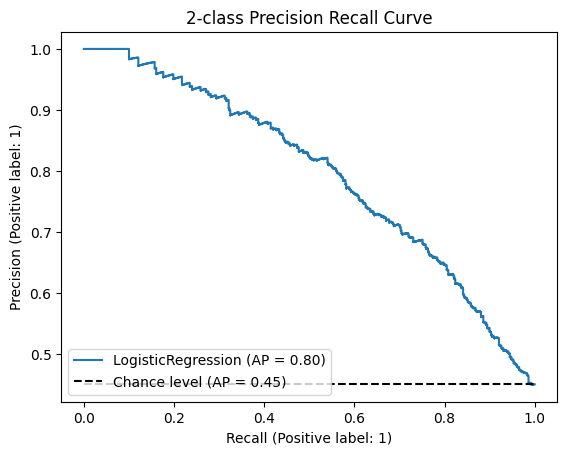

In [14]:
display = PrecisionRecallDisplay.from_estimator(
    lr_tune,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

In [25]:
# Recall on base model
y_train_pred = lr.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Base Model): {train_recall:.3f}")

# Recall on tune tune model
y_train_pred = lr_tune.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Tune Model): {train_recall:.3f}")

Recall on Training set (Base Model): 0.749
Recall on Training set (Tune Model): 0.764


### AUC Score

In [15]:
auc = roc_auc_score(y_test, y_probas)
print(f"AUC: {auc:.3f}")

auc_tune = roc_auc_score(y_test, y_probas_tune)
print(f"AUC: {auc_tune:.3f}")

AUC: 0.785
AUC: 0.799


### Cohen's Kappa

In [16]:
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.3f}")

kappa_tune = cohen_kappa_score(y_test, y_pred_tune)
print(f"Cohen's Kappa: {kappa_tune:.3f}")

Cohen's Kappa: 0.448
Cohen's Kappa: 0.435


### Confusion matrix

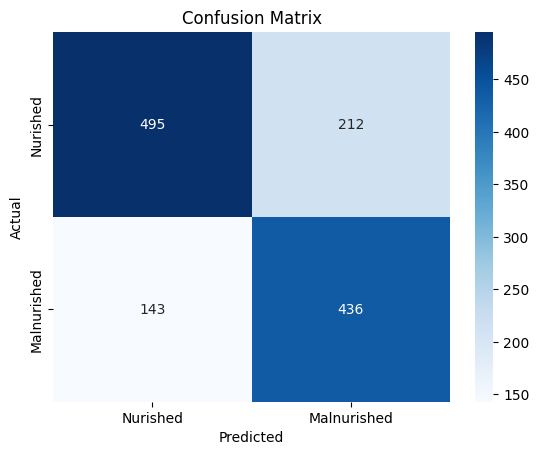

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Features importance

In [18]:
# Extract the trained classifier from the pipeline
model = lr_tune.named_steps['clf']

# Get feature names AFTER PolynomialFeatures transformation
feature_names = lr_tune.named_steps['poly'].get_feature_names_out(X_train_sm.columns)

# Get coefficients from the classifier
coefficients = model.coef_[0]  # binary classification

# Create and sort the importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance (abs)': np.abs(coefficients)
}).sort_values(by='Importance (abs)', ascending=False)

print(importance_df)


                       Feature  Coefficient  Importance (abs)
0                    child_age     0.565597          0.565597
16      child_age child_weight    -0.394029          0.394029
1                 child_weight    -0.264235          0.264235
40   child_weight province_3.0     0.208864          0.208864
34      child_weight child_sex    -0.203730          0.203730
..                         ...          ...               ...
118  province_1.0 province_5.0     0.000000          0.000000
117  province_1.0 province_4.0     0.000000          0.000000
116  province_1.0 province_3.0     0.000000          0.000000
115  province_1.0 province_2.0     0.000000          0.000000
135  province_6.0 province_7.0     0.000000          0.000000

[136 rows x 3 columns]


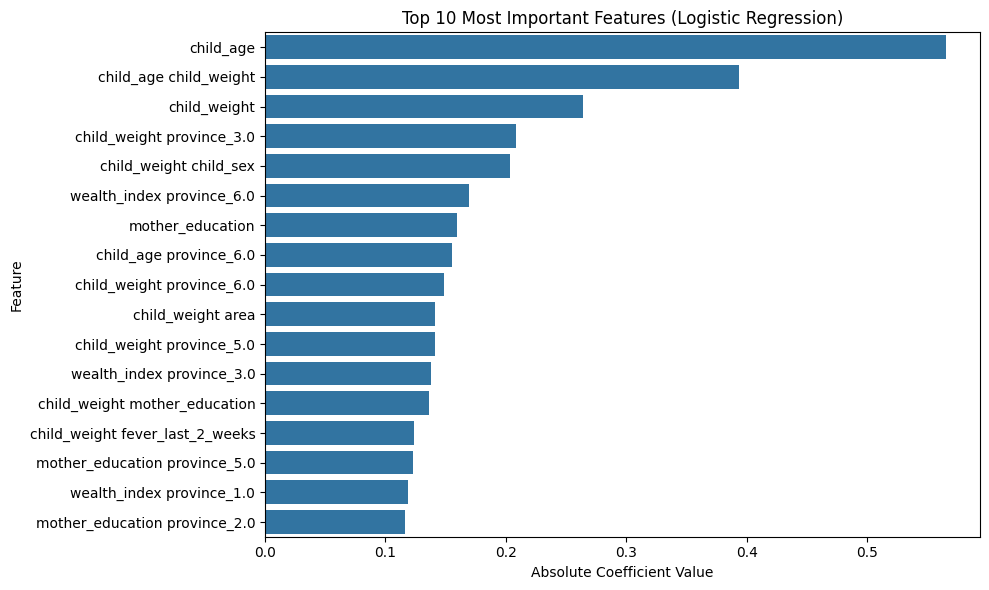

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance (abs)', y='Feature', data=importance_df.head(17))
plt.title("Top 10 Most Important Features (Logistic Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Additional

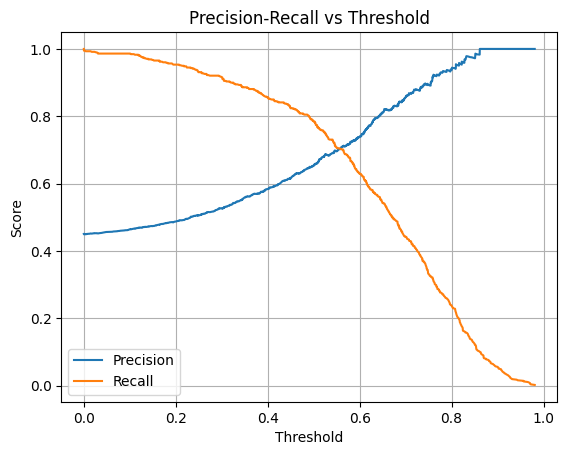

In [20]:
y_probas = lr_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [21]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.50      0.62       707
           1       0.58      0.86      0.69       579

    accuracy                           0.66      1286
   macro avg       0.70      0.68      0.66      1286
weighted avg       0.71      0.66      0.65      1286


